In [2]:
!pip install pandas 



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pandas openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

# Read Excel file
df = pd.read_excel("IPL sample data.xlsx")

# Convert to CSV
df.to_csv("ipl_match_data.csv", index=False)

print("Conversion Successful!")

Conversion Successful!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ipl_match_data.csv")
df.head()

ModuleNotFoundError: No module named 'seaborn'

In [6]:
!pip install seaborn 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip  install  matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ipl_match_data.csv")
df.head()

,Pick,Y->,Clean Pick,N->,Fumble,C->,Catch,DC->,Dropped Catch,S->,Stumping,Unnamed: 11,Unnamed: 12
0,Throw,Y->,Good Throw,N->,Bad throw,DH->,Dirct Hit,RO->,Run Out,MR->,Missed Runout,NaN,NaN
1,Runs,"""+"" stands for runs saved ""-"" stands for runs ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Match No.,Innings,Teams,Player Name,BallCount,Position,Pick,Throw,Runs,Overcount,Venue,Stadium
4,NaN,IPL2367,1,Delhi Capitals,Rilee russouw,0.1,Short mid wicket,n,NaN,1,1,Delhi,Arun Jaitly Stadium


In [13]:
import pandas as pd

# 1. Load the data properly
# We will use 'header=None' first to find where the real headers are
file_path = 'ipl_match_data.csv'  # Replace with your actual filename
raw_df = pd.read_csv(file_path, header=None)

# 2. Find the row that contains 'Match No.' or 'Player Name'
header_row_idx = -1
for i, row in raw_df.iterrows():
    if 'Match No.' in row.values or 'Player Name' in row.values:
        header_row_idx = i
        break

# 3. Reload the CSV starting from that specific row
if header_row_idx != -1:
    df = pd.read_csv(file_path, skiprows=header_row_idx)
else:
    # If not found, try skipping 3 or 4 rows as a fallback
    df = pd.read_csv(file_path, skiprows=4)

# 4. Clean up the columns (removes hidden spaces)
df.columns = df.columns.str.strip()

# --- STEP 5: Calculate the Performance Matrix ---

def calculate_player_stats(group):
    # Legend from your image: 
    # Pick: Y=Clean Pick, C=Catch, DC=Dropped Catch
    # Throw: Y=Good Throw, S=Stumping, RO=Run Out, MR=Missed Runout, DH=Direct Hit
    
    stats = {
        'Clean Picks (CP)': (group['Pick'] == 'Y').sum(),
        'Good Throws (GT)': (group['Throw'] == 'Y').sum(),
        'Catches (C)': (group['Pick'] == 'C').sum(),
        'Dropped Catches (DC)': (group['Pick'] == 'DC').sum(),
        'Stumpings (S)': (group['Throw'] == 'S').sum(),
        'Run Outs (RO)': (group['Throw'] == 'RO').sum(),
        'Missed Run Outs (MR)': (group['Throw'] == 'MR').sum(),
        'Direct Hits (DH)': (group['Throw'] == 'DH').sum(),
        'Runs Saved (RS)': pd.to_numeric(group['Runs'], errors='coerce').sum()
    }
    
    # Apply the PS Formula from your image:
    # PS = (CP*1) + (GT*1) + (C*3) - (DC*3) + (S*3) + (RO*3) - (MR*2) + (DH*2) + RS
    ps = (
        (stats['Clean Picks (CP)'] * 1) +
        (stats['Good Throws (GT)'] * 1) +
        (stats['Catches (C)'] * 3) -
        (stats['Dropped Catches (DC)'] * 3) +
        (stats['Stumpings (S)'] * 3) +
        (stats['Run Outs (RO)'] * 3) -
        (stats['Missed Run Outs (MR)'] * 2) +
        (stats['Direct Hits (DH)'] * 2) +
        stats['Runs Saved (RS)']
    )
    
    stats['Performance Score (PS)'] = ps
    return pd.Series(stats)

# Generate the matrix for all players
performance_matrix = df.groupby('Player Name').apply(calculate_player_stats).reset_index()

# 6. Final Filter for Task 3 (Advanced level): Choose 3 players
# I've chosen these from your screenshot, but you can change them
top_3_analysis = performance_matrix[performance_matrix['Player Name'].isin(['Rilee russouw', 'Lalit yadav', 'Kuldeep yadav'])]

# Display the final table
print("--- TASK 3: FIELDING PERFORMANCE MATRIX ---")
display(top_3_analysis)

--- TASK 3: FIELDING PERFORMANCE MATRIX ---


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (S),Run Outs (RO),Missed Run Outs (MR),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
6,Kuldeep yadav,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
7,Lalit yadav,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
9,Rilee russouw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


task 02 

===== FIELDING DATA =====
   Ball  CP  GT  C  DC  ST  RO  MRO  DH  RS  PS
0     1   1   1  0   0   0   0    0   0   2   4
1     2   0   1  1   0   0   1    0   1   0  15
2     3   1   0  0   0   0   0    1   0  -1  -3
3     4   1   1  0   1   0   0    0   0   3   1
4     5   0   1  1   0   0   0    0   0   1   7
5     6   1   1  0   0   0   0    0   0   2   4
6     7   1   0  0   1   0   1    0   1   0   6
7     8   0   1  1   0   0   0    0   0   1   7
8     9   1   1  0   0   0   0    1   0  -2  -3
9    10   0   1  0   0   0   0    0   0   2   3

Total Match Fielding Performance Score: 41

===== DATA SUMMARY =====
           Ball         CP         GT          C         DC    ST         RO  \
count  10.00000  10.000000  10.000000  10.000000  10.000000  10.0  10.000000   
mean    5.50000   0.600000   0.800000   0.300000   0.200000   0.0   0.200000   
std     3.02765   0.516398   0.421637   0.483046   0.421637   0.0   0.421637   
min     1.00000   0.000000   0.000000   0.000000   0.000

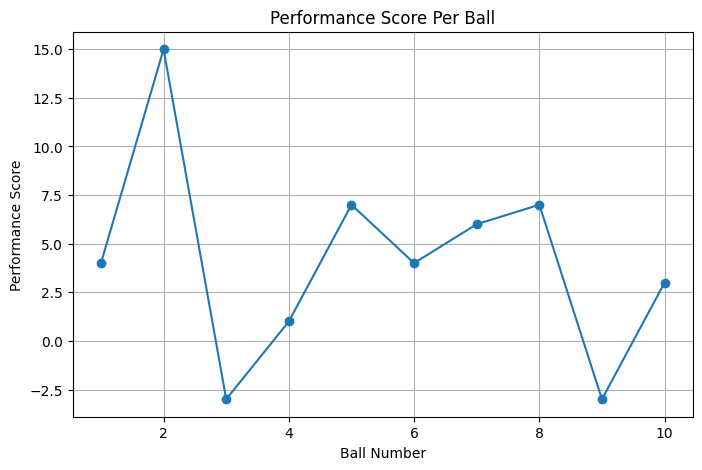

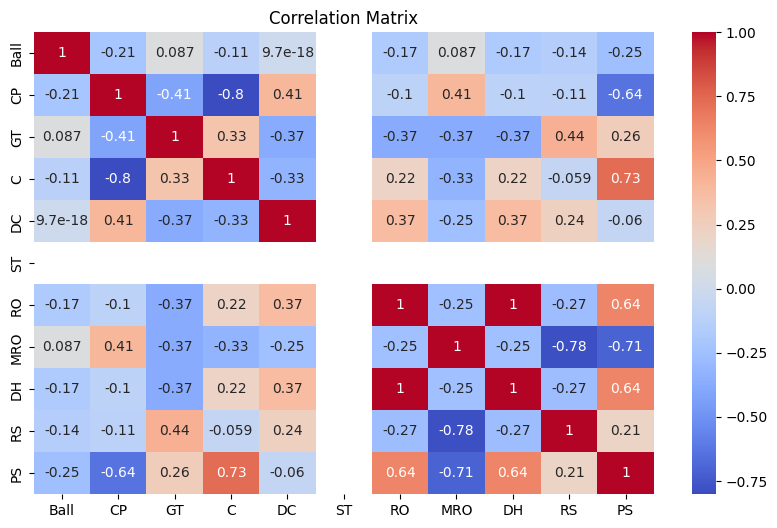

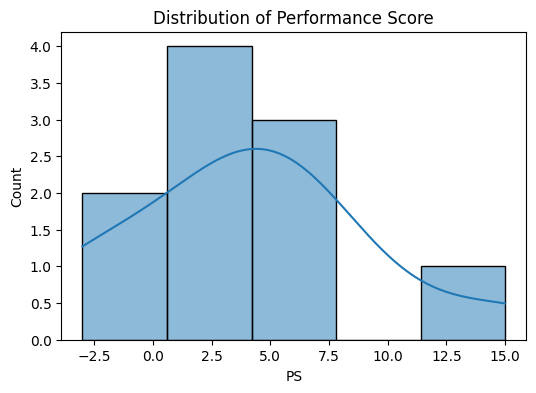


Excel file saved as 'Fielding_Performance_Output.xlsx'
Analysis Completed Successfully ✅


In [ ]:
# ================================
# FIELDING PERFORMANCE ANALYSIS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ CREATE SAMPLE FIELDING DATA
# -------------------------------

data = {
    "Ball": [1,2,3,4,5,6,7,8,9,10],
    "CP": [1,0,1,1,0,1,1,0,1,0],      # Clean Picks
    "GT": [1,1,0,1,1,1,0,1,1,1],      # Good Throws
    "C": [0,1,0,0,1,0,0,1,0,0],       # Catches
    "DC": [0,0,0,1,0,0,1,0,0,0],      # Dropped Catches
    "ST": [0,0,0,0,0,0,0,0,0,0],      # Stumpings
    "RO": [0,1,0,0,0,0,1,0,0,0],      # Run Outs
    "MRO": [0,0,1,0,0,0,0,0,1,0],     # Missed Run Outs
    "DH": [0,1,0,0,0,0,1,0,0,0],      # Direct Hits
    "RS": [2,0,-1,3,1,2,0,1,-2,2]     # Runs Saved
}

df = pd.DataFrame(data)

# -------------------------------
# 2️⃣ DEFINE WEIGHTS
# -------------------------------

WCP = 1
WGT = 1
WC = 5
WDC = -4
WST = 6
WRO = 4
WMRO = -3
WDH = 5

# -------------------------------
# 3️⃣ CALCULATE PERFORMANCE SCORE
# -------------------------------

df["PS"] = (
    (df["CP"] * WCP) +
    (df["GT"] * WGT) +
    (df["C"] * WC) +
    (df["DC"] * WDC) +
    (df["ST"] * WST) +
    (df["RO"] * WRO) +
    (df["MRO"] * WMRO) +
    (df["DH"] * WDH) +
    df["RS"]
)

# -------------------------------
# 4️⃣ TOTAL MATCH SCORE
# -------------------------------

total_score = df["PS"].sum()

print("===== FIELDING DATA =====")
print(df)
print("\nTotal Match Fielding Performance Score:", total_score)

# -------------------------------
# 5️⃣ BASIC DATA ANALYSIS (EDA)
# -------------------------------

print("\n===== DATA SUMMARY =====")
print(df.describe())

# -------------------------------
# 6️⃣ VISUALIZATIONS
# -------------------------------

# Performance Score per Ball
plt.figure(figsize=(8,5))
plt.plot(df["Ball"], df["PS"], marker="o")
plt.title("Performance Score Per Ball")
plt.xlabel("Ball Number")
plt.ylabel("Performance Score")
plt.grid(True)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Distribution of Performance Score
plt.figure(figsize=(6,4))
sns.histplot(df["PS"], bins=5, kde=True)
plt.title("Distribution of Performance Score")
plt.show()

# -------------------------------
# 7️⃣ SAVE TO EXCEL (OPTIONAL)
# -------------------------------

df.to_excel("Fielding_Performance_Output.xlsx", index=False)

print("\nExcel file saved as 'Fielding_Performance_Output.xlsx'")
print("Analysis Completed Successfully ✅")

===== DATA PREVIEW =====
        Date  Gross_Sales    COGS  Manufacturing_Cost  Freight_Cost  \
0 2022-01-31       321958  149092              111211         48952   
1 2022-02-28       346867   83890              105697         32662   
2 2022-03-31       331932  121606               77065         18392   
3 2022-04-30       459178  176276               72606         40535   
4 2022-05-31       319879  160038               51534         23067   

   Net_Sales  Total_Cost  Profit  Profit_Margin_%  Fiscal_Year  
0     172866      309255   12703         3.945546         2021  
1     262977      222249  124618        35.926738         2021  
2     210326      217063  114869        34.606184         2021  
3     282902      289417  169761        36.970630         2022  
4     159841      234639   85240        26.647576         2022  

===== SUMMARY STATISTICS =====
                      Date    Gross_Sales           COGS  Manufacturing_Cost  \
count                   36      36.000000     

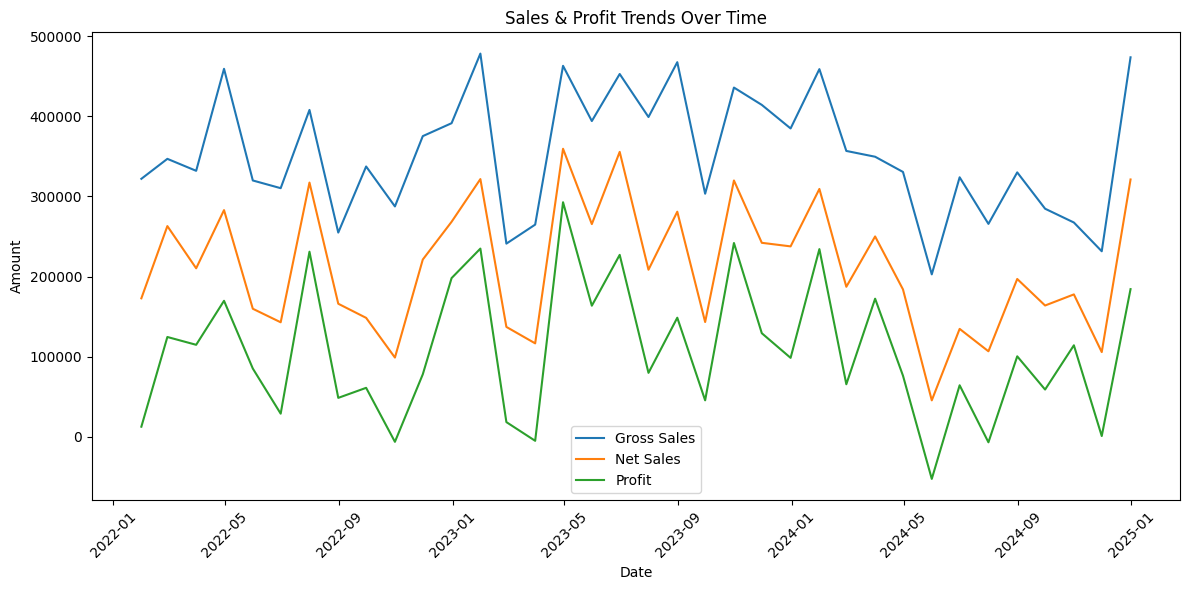

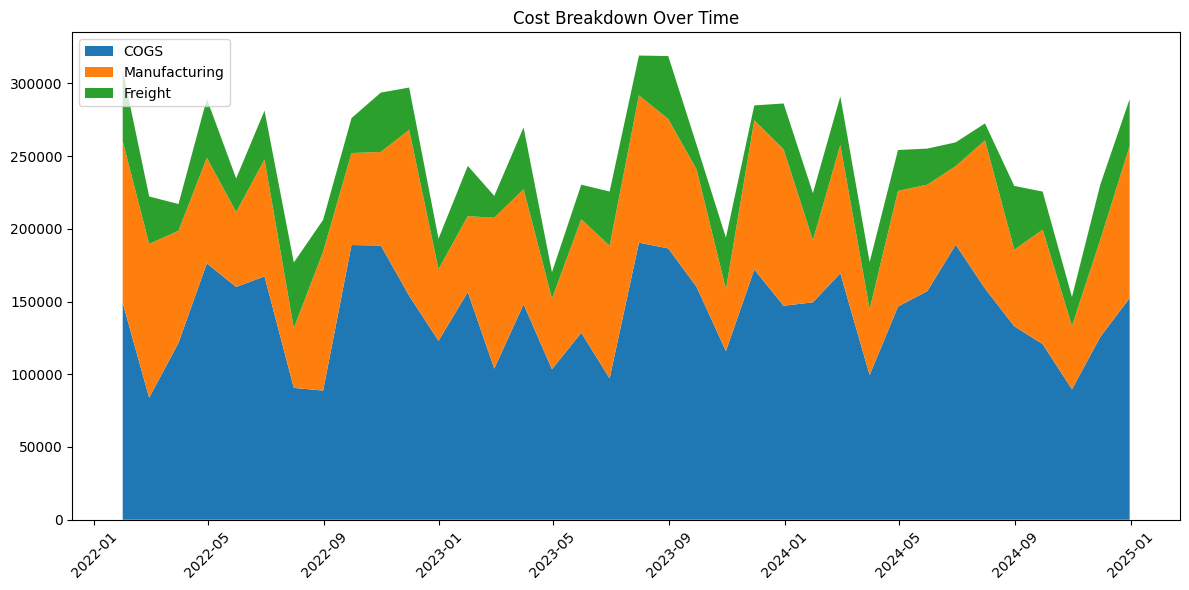

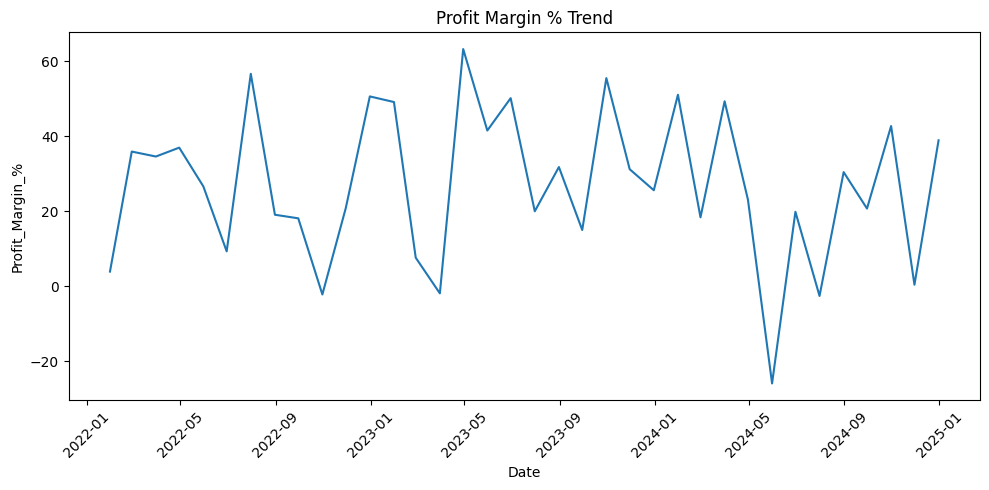

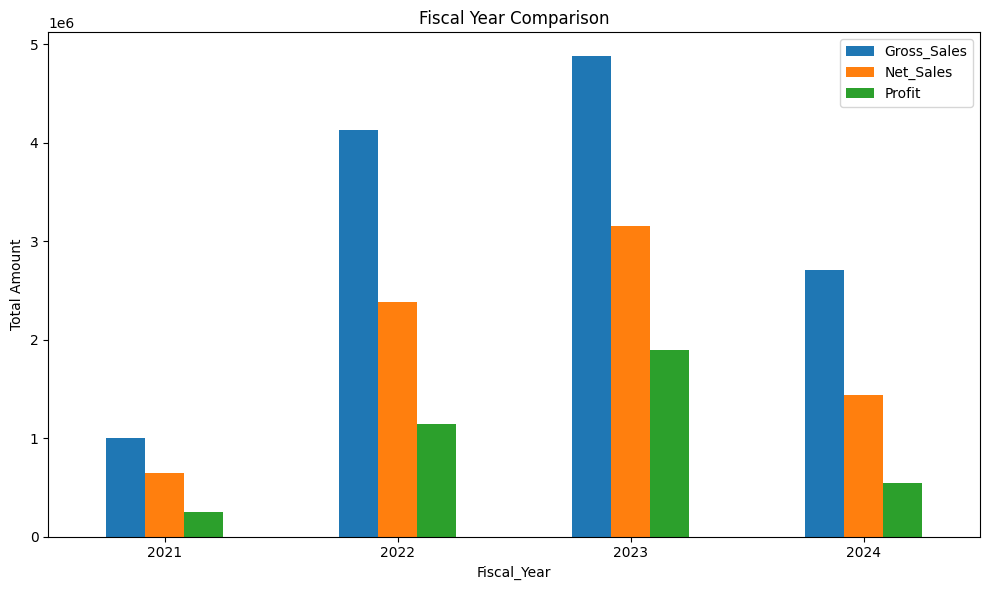

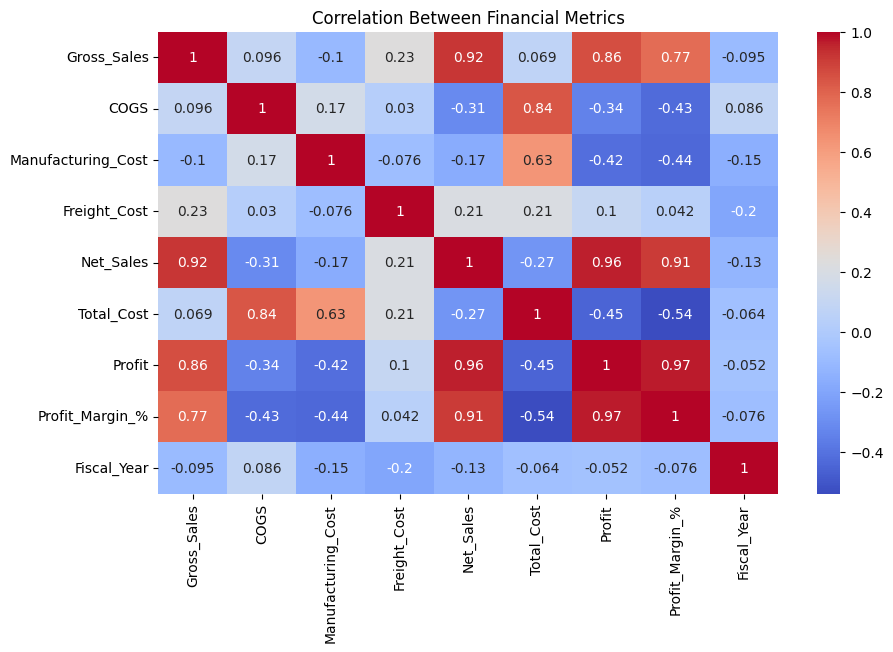


Analysis Completed Successfully ✅
Excel file saved as 'Advanced_Sales_Analysis_Output.xlsx'


In [16]:
# ======================================================
# ADVANCED SALES DATA ANALYSIS WITH FINANCIAL METRICS
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------
# 1️⃣ CREATE SAMPLE SALES DATASET
# ------------------------------------------------------

np.random.seed(42)

# ✅ FIXED HERE → freq="ME"
dates = pd.date_range(start="2022-01-01", end="2024-12-31", freq="ME")

data = pd.DataFrame({
    "Date": dates,
    "Gross_Sales": np.random.randint(200000, 500000, len(dates)),
    "COGS": np.random.randint(80000, 200000, len(dates)),
    "Manufacturing_Cost": np.random.randint(40000, 120000, len(dates)),
    "Freight_Cost": np.random.randint(10000, 50000, len(dates))
})

# ------------------------------------------------------
# 2️⃣ CALCULATE FINANCIAL METRICS
# ------------------------------------------------------

data["Net_Sales"] = data["Gross_Sales"] - data["COGS"]
data["Total_Cost"] = (
    data["COGS"] +
    data["Manufacturing_Cost"] +
    data["Freight_Cost"]
)

data["Profit"] = data["Gross_Sales"] - data["Total_Cost"]
data["Profit_Margin_%"] = (data["Profit"] / data["Gross_Sales"]) * 100

# Create Fiscal Year (April–March system)
data["Fiscal_Year"] = data["Date"].dt.year
data.loc[data["Date"].dt.month < 4, "Fiscal_Year"] -= 1

print("===== DATA PREVIEW =====")
print(data.head())

# ------------------------------------------------------
# 3️⃣ SUMMARY STATISTICS
# ------------------------------------------------------

print("\n===== SUMMARY STATISTICS =====")
print(data.describe())

# ------------------------------------------------------
# 4️⃣ TIME SERIES ANALYSIS
# ------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["Gross_Sales"], label="Gross Sales")
plt.plot(data["Date"], data["Net_Sales"], label="Net Sales")
plt.plot(data["Date"], data["Profit"], label="Profit")
plt.title("Sales & Profit Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 5️⃣ COST BREAKDOWN (STACKED AREA)
# ------------------------------------------------------

plt.figure(figsize=(12,6))
plt.stackplot(
    data["Date"],
    data["COGS"],
    data["Manufacturing_Cost"],
    data["Freight_Cost"],
    labels=["COGS", "Manufacturing", "Freight"]
)
plt.legend(loc="upper left")
plt.title("Cost Breakdown Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 6️⃣ PROFIT MARGIN TREND
# ------------------------------------------------------

plt.figure(figsize=(10,5))
sns.lineplot(x="Date", y="Profit_Margin_%", data=data)
plt.title("Profit Margin % Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 7️⃣ FISCAL YEAR COMPARISON
# ------------------------------------------------------

fiscal_summary = data.groupby("Fiscal_Year")[["Gross_Sales", "Net_Sales", "Profit"]].sum()

fiscal_summary.plot(kind="bar", figsize=(10,6))
plt.title("Fiscal Year Comparison")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 8️⃣ CORRELATION HEATMAP
# ------------------------------------------------------

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Financial Metrics")
plt.show()

# ------------------------------------------------------
# 9️⃣ SAVE OUTPUT
# ------------------------------------------------------

data.to_excel("Advanced_Sales_Analysis_Output.xlsx", index=False)

print("\nAnalysis Completed Successfully ✅")
print("Excel file saved as 'Advanced_Sales_Analysis_Output.xlsx'")